# **Diplomado IA: Inteligencia Artificial I - Parte 2**. <br> Práctico 1: Grafo cómputo, inicialización de pesos y funciones activación
---
---

**Profesores:**
- Carlos Aspillaga
- Gabriel Sepúlveda

**Ayudante:**
- Bianca del Solar
---
---

# **Instrucciones Generales**

El siguiente práctico se debe realizar de forma **individual**. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código como respuesta.

**Nombre alumno:**. Roberto Araneda

El siguiente práctico cuanta con 2 secciones donde cada una contendrá 1 o más actividades a realizar. Algunas actividades correspondrán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.

**Fecha de entrega:** domingo 12 de abril de 2026, 23:59 hrs.

# **Funciones de Activación**

## Experimento 1: Explorando y visualizando las funciones de activación

Para esta etapa, vamos a explorar una función de activación, ver que valores posibles puede retornar y que gradientes puede devolver.

Primero vamos a definir una función de activacion, en este caso la `ReLU` (https://pytorch.org/docs/stable/nn.html#relu).

**Pytorch tip 1:** Para utilizar las funcionalidades de pytorch, debemos como primer paso imporate el paquete torch mediate: *import torch*

**Pytorch tip 2:** Para acceder a las funciones de activación, utilizaremos el módulo torch.nn. Las funciones de activación deberán ser instanciadas como un objeto de la clase en cuestión. Por ejemplo: *torch.nn.ReLU()*.

In [12]:
import torch

#activation_function = torch.nn.ReLU()
activation_function = torch.nn.Sigmoid()

print(activation_function)

ReLU()


Luego vamos a utilizar dicha funcion para ver cual es la salida ante un valor positivo, el 0 y uno negativo.

**Pytorch tip:** Aquí es importante notar que utilizaremos un tipo de dato Tensor del framework pytorch. Como su nombre lo indica, este tipo de dato permite la creación y manejo de tensores, que son la unidad fundamental para el flujo de las operaciones matemáticas definidas en cualquier arquitectura. En el caso particular del ejemplo, crearemos tendores de 1 dimensión a partir de una lista de python.

In [8]:
x = torch.Tensor([2])
positivo = activation_function(x)
print( 'Función evaluada en un valor positivo: %d' % (positivo))

x = torch.Tensor([0])
cero = activation_function(x)
print( 'Función evaluada en el cero: %d' % (cero))

x = torch.Tensor([-9])
negativo = activation_function(x)
print( 'Función evaluada en un valor negativo: %d' % (negativo))

Función evaluada en un valor positivo: 0
Función evaluada en el cero: 0
Función evaluada en un valor negativo: 0


Ahora vamos a graficar todos los valores posible que puede tomar un valor ente -10 y 10 cuando se le aplica una función de activación.

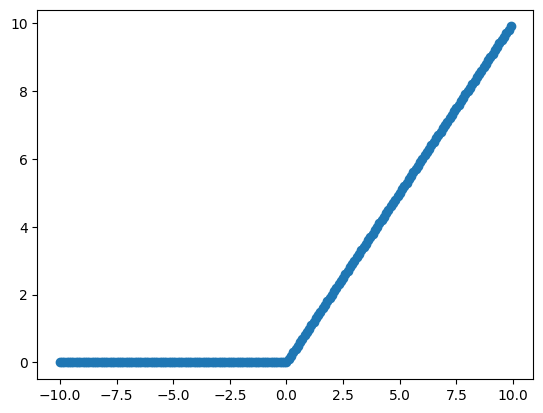

In [13]:
import matplotlib.pyplot as plt

import numpy

X = []
Fx = []

# Recorremos todos los valores entre -10 a 10 con diferencia de 0.1 entre cada valor
for x in numpy.arange(-10, 10, 0.1):
    X.append(x)
    x = torch.Tensor([x])
    result = activation_function(x)
    Fx.append(float(result)) # convert Tensor() to float(), and append it into list

plt.scatter(X, Fx)

plt.show()

Ahora obtendremos el valor del gradiente (derivada) que devuelve la función de activación ReLU en su parte lineal. Para ello utilizaremos el método *backward* sobre el tensor de resultado (salida de ReLU), para iniciar la retro-propagación de los gradientes. El proceso de cálculo que hay detrás de este método, es el mismo analizado para el cálculo de gradientes mediante grafos de cómputo.

**Pytorch tip:** Aquí introduciremos un nuevo tipo de dato llamado *Variable*. Esta clase es simplemente un *wrapper* para de la clase Tensor, que permite mantener en memoria los datos necesarios para el cálculo de los gradientes y la estructura del grafo de cómputo. Para ello, es necesario entregar como argumento el tensor a utilizar, y el parámetro *requires_grad* con valor True. Para efectos operativos, *Variable* se comporta exactamente igual que *Tensor*.

In [14]:
from torch.autograd import Variable

# Definimos el valor de entrada e indicamos que debe almacenar el gradiente
#x = Variable(torch.Tensor([2]), requires_grad=True)
x = torch.tensor([2.0], requires_grad=True)

result = activation_function(x)

# Aplicamos el paso "backward" para propagar los gradientes
# grad = df/dx * dx/dx
result.backward()

print( 'Función:    %s' % (activation_function))
print( 'Input:      %f' % (x.item()))
print( 'Output:     %f' % (result))
print( 'Gradiente:  %f' % (x.grad))

Función:    ReLU()
Input:      2.000000
Output:     2.000000
Gradiente:  1.000000


Finalmente vamos a graficar todos los gradientes calculados al ingresar valores entre -10 y 10, o en otras palabras, vamos a graficar la derivada de la función de activación para dicho rango.

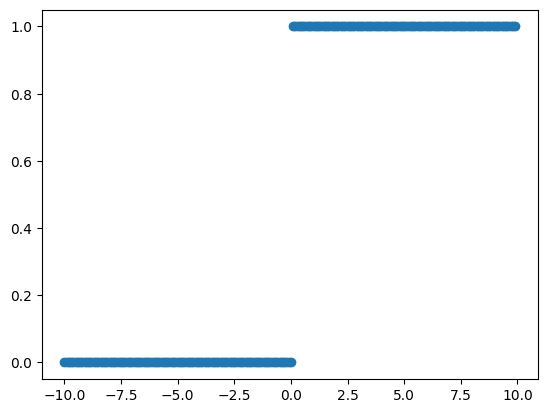

In [15]:
X = []
gradiente = []

# Recorremos todos los valores entre -10 a 10 con diferencia de 0.1 entre cada valor
for x in numpy.arange(-10, 10, 0.1):
    X.append(x)
    x = Variable(torch.Tensor([x]), requires_grad=True)
    result = activation_function(x)
    result.backward()
    gradiente.append(float(x.grad))

plt.scatter(X, gradiente)
plt.show()

## Actividad 2.1

En el siguiente link: https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity se presenta un conjunto de funciones de activacion. Utilice la función `Sigmoid` para:
1. Confeccionar el gráfico de la función
2. Confeccionar el gráfico de su derivada

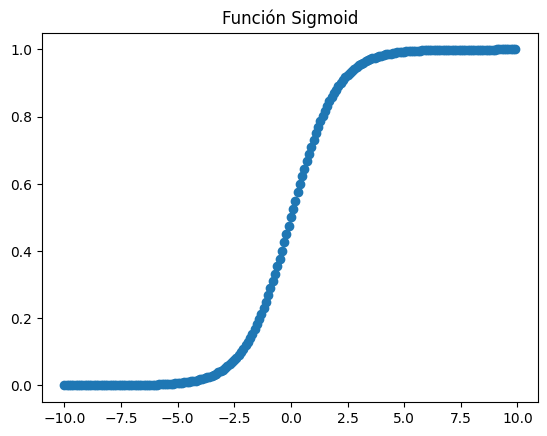

In [16]:
# Código para confeccionar el gráfico de la función

import matplotlib.pyplot as plt
import numpy

activation_function = torch.nn.Sigmoid()

X = []
Fx = []

for x in numpy.arange(-10, 10, 0.1):
    X.append(x)
    x = torch.Tensor([x])
    result = activation_function(x)
    Fx.append(float(result))

plt.scatter(X, Fx)
plt.title('Función Sigmoid')
plt.show()



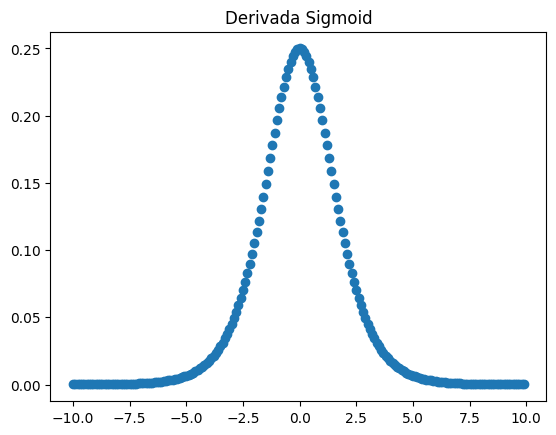

In [18]:
# Código para confeccionar el gráfico de su derivada

from torch.autograd import Variable

X = []
gradiente = []

for x in numpy.arange(-10, 10, 0.1):
    X.append(x)
    x = Variable(torch.Tensor([x]), requires_grad=True)
    result = activation_function(x)
    result.backward()
    gradiente.append(float(x.grad))

plt.scatter(X, gradiente)
plt.title('Derivada Sigmoid')
plt.show()


## Actividad 2.2

Responda la siguiente pregunta.

**1** - Entre un modelo con función de activación ReLU y otro con función de activación Sigmoidal, ¿ Cual cree usted que aprendería más rápido ?. Justifique su respuesta apoyandose en los gráficos generados anteriormente.

**Respuesta**:

Creo que ReLU aprende más rápido, porque en la derivada de Sigmoid el gradiente máximo es 0.25, con valores mayores o menores que 3 por ejemplo, el gradiente se acerca a 0, por lo que las neuronas reciben actualizaciones de pesos muy pequeños.

Por otro lado, la derivada de ReLU para todo x mayor que 0, el gradiente es 1 (constante), es decir 4 veces má rápido que una sigmoid (0,25).


Si quedaste con ganas de explorar otras funciones de activacion y visualizar sus derivadas. Recomendamos la siguiente página: https://dashee87.github.io/deep%20learning/visualising-activation-functions-in-neural-networks/

# **Inicialización de Pesos**

En la siguiente sección analizaremos el afecto que tiene el criterio de inicialización de pesos escogido, sobre el proceso de entrenamiento de una red neuronal profunda.

Para ello, crearemos una red neuronal de 10 capas, que recibirá como entrada un vector de 2 dimensiones, y entregará a la salida un único valor. Esta red será construida sin utilizar función de activación en ninguna de sus capas, con el objetivo de medir de forma aislada el efecto de los valores iniciales de los pesos. La siguiente figura, muestra un esquema de la red neuronal diseñada:

<img src="https://imgur.com/O9acV99.png"/>




## Experimento 1: Inicialización con valor constante

Antes de comenzar, importaremos los paquetes necesarios para el desarrollo de esta sección. Con ellos, definiremos la función *plot_variable* que nos permitirá graficar de forma sencilla el valor de los gradientes, y la función *fit*, que implementará el loop de entrenamiento entregando como único valor de entrada el vector $[0.5, 0.5]$, para la predicción del valor 1.

Por ahora, no nos enfocaremos en su implementación.

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [20]:
def plot_variable( grads, varname ):
  plt.figure( figsize=(9, 6) )
  ax = plt.axes()
  ax.set_xlabel( 'Training step' )
  ax.set_ylabel( varname )
  ax.plot( grads )
  ax.update_datalim( list( zip( range(len(grads)), grads ) ) )
  ax.autoscale()

In [21]:
def fit( model ):
  mse_lossfunc = nn.MSELoss()
  optimizer = optim.Adam( model.parameters(), lr = 1e-4 )
  x = torch.Tensor( [0.5, 0.5] )
  y = torch.Tensor( [1] )
  gradients = list()
  loss_seq = list()
  for i in range( 200 ):
    # 1. Forward: predice con entrada [0.5, 0.5]
    p = model( x )

    # 2. Calcula el error (prediccion vs 1)
    loss_value = mse_lossfunc( p, y )

    # 3. Limpia gradientes del paso anterior
    optimizer.zero_grad()

    # 4. Backward: calcula gradientes
    loss_value.backward()

    # 5. Actualiza pesos usando Adam (lr=0.0001)
    optimizer.step()
    gradients.append( model.layer_0.weight.grad[0,:] )
    loss_seq.append( loss_value.item() )
  gradients = torch.stack( gradients )
  loss_seq = torch.Tensor( loss_seq )
  plot_variable( gradients[:,0], 'Gradient' )
  plot_variable( loss_seq, 'Loss' )

En el siguiente código hemos definido el modelo *DeepNN*. Éste implementa una red neuronal con 9 capas ocultas de 2 neuronas, y una capa de salida de 1 neurona, y sin utilizar función de activación.

Cada capa es definida mediante la creación de un objeto de la clase *Linear* de torch, las cuales son almacenadas dentro de los atributos de nombre *layer_x*. Una vez creadas las 10 capas, utilizaremos la función *init.constant_* de torch para inicializar los pesos de cada capa a un valor constante, el cual es definido por un parámetro del constructor de la clase.

In [22]:
class DeepNN( nn.Module ):

  def __init__( self, weights_initial_value ):
    super( DeepNN, self ).__init__()
    self.layer_0 = torch.nn.Linear( 2, 2 )
    self.layer_1 = torch.nn.Linear( 2, 2 )
    self.layer_2 = torch.nn.Linear( 2, 2 )
    self.layer_3 = torch.nn.Linear( 2, 2 )
    self.layer_4 = torch.nn.Linear( 2, 2 )
    self.layer_5 = torch.nn.Linear( 2, 2 )
    self.layer_6 = torch.nn.Linear( 2, 2 )
    self.layer_7 = torch.nn.Linear( 2, 2 )
    self.layer_8 = torch.nn.Linear( 2, 2 )
    self.layer_9 = torch.nn.Linear( 2, 1 )
    torch.nn.init.constant_( self.layer_0.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_1.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_2.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_3.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_4.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_5.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_6.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_7.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_8.weight.data, weights_initial_value )
    torch.nn.init.constant_( self.layer_9.weight.data, weights_initial_value )

  def forward( self, x ):
    x = self.layer_0(x)
    x = self.layer_1(x)
    x = self.layer_2(x)
    x = self.layer_3(x)
    x = self.layer_4(x)
    x = self.layer_5(x)
    x = self.layer_6(x)
    x = self.layer_7(x)
    x = self.layer_8(x)
    x = self.layer_9(x)
    return x

### Inicialización de pesos con valores menor a 1

Nuestro primer experimento consistirá en iniciazar la red con todos sus pesos con un valor menor que uno. En particular, el valor escogido es 0.1.

In [23]:
model = DeepNN( 0.1 )
print(model.layer_0.weight.data)

tensor([[0.1000, 0.1000],
        [0.1000, 0.1000]])


Ahora, veamos que pasa con los gradientes y la pérdida al entrenar el modelo.

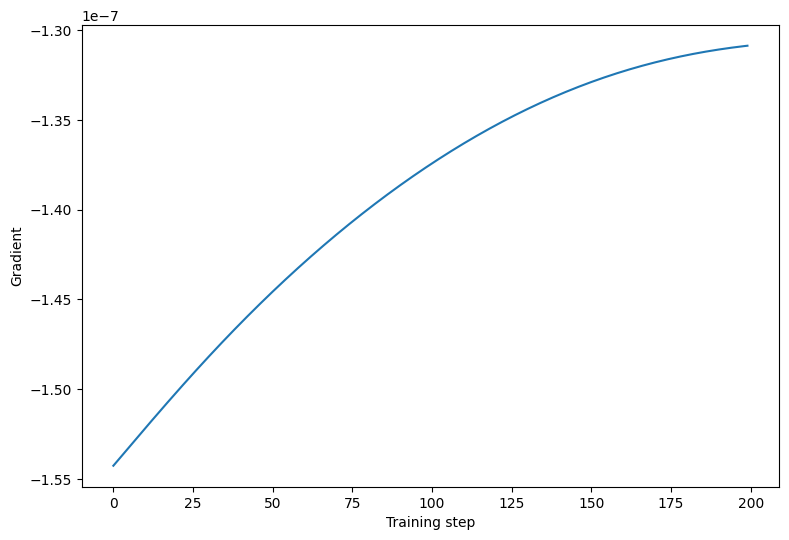

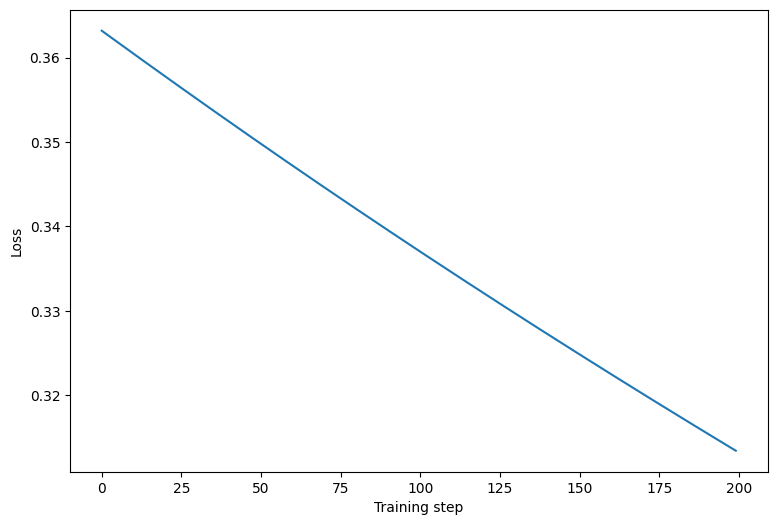

In [24]:
fit(model)

### Inicialización de pesos con valores mayor a 1

En el presente experimento, inicializaremos la red con todos sus pesos con un valor mayor a 1. En particular, el valor escogido es 1.5.

In [25]:
model = DeepNN( 1.5 )
print(model.layer_0.weight.data)

tensor([[1.5000, 1.5000],
        [1.5000, 1.5000]])


Ahora, veamos que pasa con los gradientes y la pérdida al entrenar el modelo.

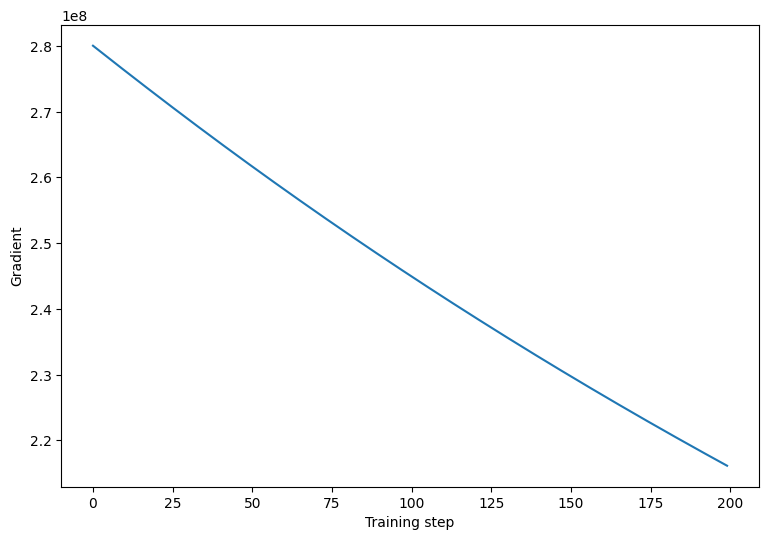

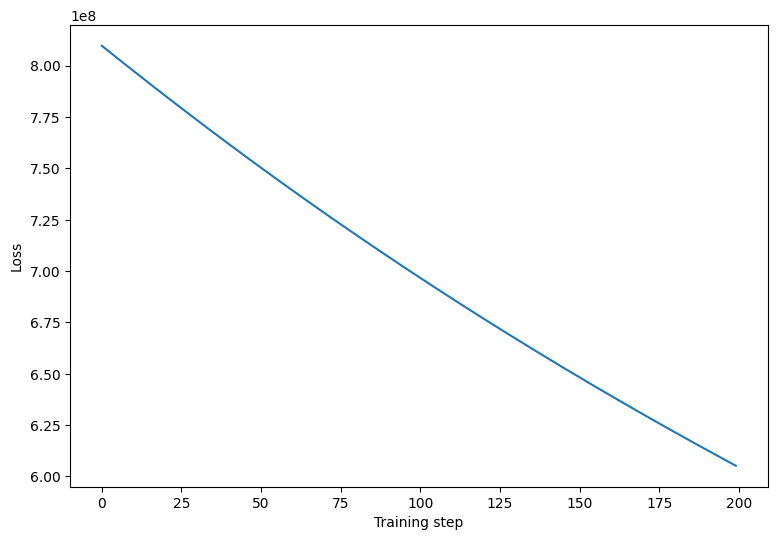

In [26]:
fit(model)

## Actividades

### Actividad 3.1

Responda las siguientes preguntas

¿ Como se llama el fenómeno observado al inicializar los pesos con valores menor a 1 ?

**Respuesta:**

Desvanecimiento de gradiente. Los pesos menores a 1 multiplican todas las capas y el valor se va reduciendo exponencialmente.

¿ Como se llama el fenómeno observado al inicializar los pesos con valores mayor a 1 ?

**Respuesta:**

Explosión de gradiente. Los pesos mayores a 1 se van multiplicando en todas las capas y el valor crece exponencialmente.

### Actividad 3.2

Repita el ejercicio anterior, pero esta vez, incializando los pesos a través del método de Xavier Glorot.

Para ello deberá re-definir el modelo y reemplazar la función de inicialización por la función *torch.nn.init.xavier_uniform_*. Para mayor detalle sobre esta función, visite el sitio: [Pytorch Xavier Uniform](https://pytorch.org/docs/stable/nn.init.html#torch.nn.init.xavier_uniform_)

In [27]:
# Ingrese el código para el modelo de su red

class DeepNNXavier( nn.Module ):

  def __init__( self):
    super( DeepNNXavier, self ).__init__()
    self.layer_0 = torch.nn.Linear( 2, 2 )
    self.layer_1 = torch.nn.Linear( 2, 2 )
    self.layer_2 = torch.nn.Linear( 2, 2 )
    self.layer_3 = torch.nn.Linear( 2, 2 )
    self.layer_4 = torch.nn.Linear( 2, 2 )
    self.layer_5 = torch.nn.Linear( 2, 2 )
    self.layer_6 = torch.nn.Linear( 2, 2 )
    self.layer_7 = torch.nn.Linear( 2, 2 )
    self.layer_8 = torch.nn.Linear( 2, 2 )
    self.layer_9 = torch.nn.Linear( 2, 1 )
    torch.nn.init.xavier_uniform_(self.layer_0.weight.data)
    torch.nn.init.xavier_uniform_(self.layer_1.weight.data)
    torch.nn.init.xavier_uniform_(self.layer_2.weight.data)
    torch.nn.init.xavier_uniform_(self.layer_3.weight.data)
    torch.nn.init.xavier_uniform_(self.layer_4.weight.data)
    torch.nn.init.xavier_uniform_(self.layer_5.weight.data)
    torch.nn.init.xavier_uniform_(self.layer_6.weight.data)
    torch.nn.init.xavier_uniform_(self.layer_7.weight.data)
    torch.nn.init.xavier_uniform_(self.layer_8.weight.data)
    torch.nn.init.xavier_uniform_(self.layer_9.weight.data)

  def forward( self, x ):
    x = self.layer_0(x)
    x = self.layer_1(x)
    x = self.layer_2(x)
    x = self.layer_3(x)
    x = self.layer_4(x)
    x = self.layer_5(x)
    x = self.layer_6(x)
    x = self.layer_7(x)
    x = self.layer_8(x)
    x = self.layer_9(x)
    return x

In [28]:
# Ingrese el código para crear una instancia de su modelo

model = DeepNNXavier()
print(model.layer_0.weight.data)

tensor([[ 1.1083, -0.2710],
        [-1.0929,  0.5795]])


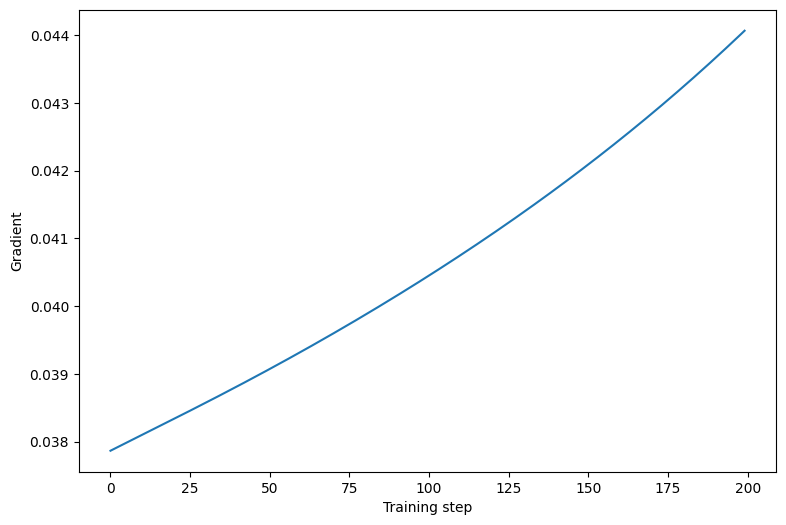

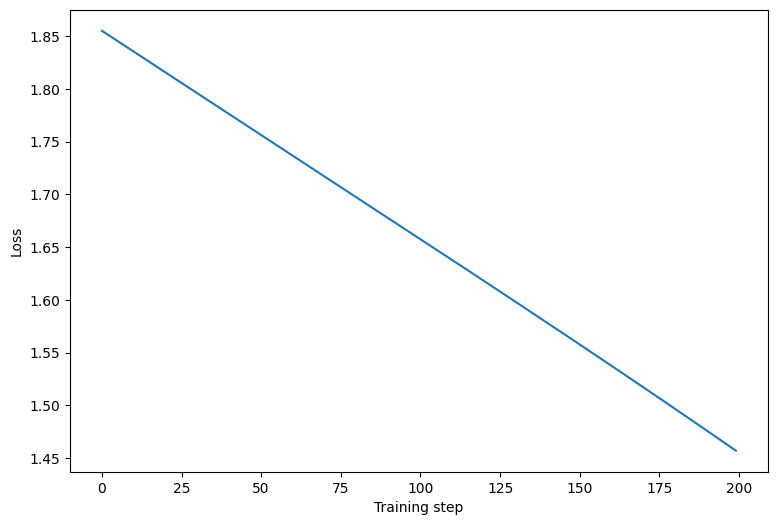

In [29]:
# Ingrese el código que llama a la función fit, entregando su modelo como parámetro

fit(model)

¿ Qué efecto puede ver de la aplicación de este nuevo método de inicialización de pesos ?

**Respuesta:**

Que los gradientes se mantienen en un rango razonable, es decir no hay desvanecimiento ni explosión. La función de pérdica desciende de forma consistente, no en valores extremadamente pequeños o en valores extremadamente grandes.

¿ A que se deben los efectos observados ?

**Respuesta:**

Porque con el método de Xavier Glorot inicializa los pesos con varianza de 2 / (fan_in + fan_out), lo que asegura que la varianza de la señal se mantenga igual entre la entrada y salida de cada capa. Con esto se evita el vanishing y el exploding.